## Regression

In [30]:
import torch
import pandas as pd
import numpy as np

In [31]:
df = pd.read_csv("powerplant_data.csv")

In [32]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [33]:
# AT => temperature
# V => vaccum
# AP => pressure
# RH => humidity
# PE => producted output/energy

In [34]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [35]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [36]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [37]:
#!pip install scikit-learn

In [38]:
# Split our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [39]:
#type(X_train)

In [40]:
df.shape

(9568, 5)

In [41]:
# Scaled the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# convert into tensor

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [43]:
# TensorDataset
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [44]:
# DataLoader
trian_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [45]:
## ANN 
import torch.nn as nn
import torch.nn.functional as F

class ANN(nn.Module) :
    def __init__(self) :
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1)
        )
    
    def forward(self, x) :
        return self.model(x)

In [46]:
import torch.optim as optim

model = ANN()

# loss optimizer
critetrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [47]:
# loss -> loss for one batch
# running loss -> loss for all the batch
# training loss = average loss per batch -> running batch / loss for all the batch

# Train the ANN

train_loss = []
valid_loss = []

best_val_loss = float("inf")

epochs = 100
for epoch in range(epochs) :
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in trian_loader :
        # xb = features of 1 batch
        # yb = lables of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward propagration predicted outputs for this batch
        loss = critetrion(outputs, yb) # compute loss
        loss.backward() # back propagration compute gradients
        optimizer.step() # parameter update

        running_loss += loss.item() # loss is a tensor -> py float

    epoch_train_loss = running_loss / len(trian_loader)
    train_loss.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad() : # no gradients compute
        for xb, yb in test_loader :
            outputs = model(xb)
            loss = critetrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_loss.append(epoch_val_loss)

    print(f"epoch ${epoch + 1}/{epochs} -> train loss = ${epoch_train_loss} & validation loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch $1/100 -> train loss = $206419.79837239583 & validation loss = $205279.796875
epoch $2/100 -> train loss = $200989.50091145834 & validation loss = $193307.25
epoch $3/100 -> train loss = $179348.71725260417 & validation loss = $161872.59375
epoch $4/100 -> train loss = $139753.31751302083 & validation loss = $116258.703125
epoch $5/100 -> train loss = $93767.23321940104 & validation loss = $73041.3828125
epoch $6/100 -> train loss = $57552.679459635416 & validation loss = $44679.58984375
epoch $7/100 -> train loss = $36475.758634440106 & validation loss = $29324.724609375
epoch $8/100 -> train loss = $25108.588028971353 & validation loss = $21076.693359375
epoch $9/100 -> train loss = $18888.171765136718 & validation loss = $16401.42578125
epoch $10/100 -> train loss = $15062.421171061198 & validation loss = $13187.7275390625
epoch $11/100 -> train loss = $12092.427207438152 & validation loss = $10484.7880859375
epoch $12/100 -> train loss = $9519.134073893229 & validation loss =

In [48]:
#!pip install matplotlib

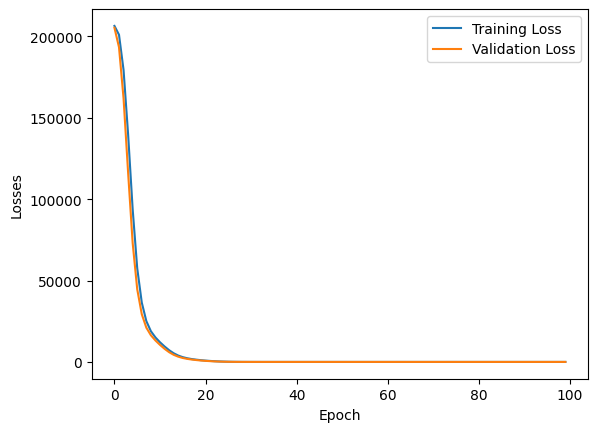

In [49]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_loss,
    "Validation Loss": valid_loss
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Losses")

plt.legend()

In [50]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [53]:
# Evaluate the model

model.eval()
with torch.no_grad() :
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = critetrion(train_preds, y_train_tensor)
    test_mse_loss = critetrion(test_preds, y_test_tensor)

print("Train MSE: ", train_mse_loss.item())
print("Test MSE: ", test_mse_loss.item())

Train MSE:  20.497709274291992
Test MSE:  18.806983947753906


In [54]:
from sklearn.metrics import r2_score

print("r2_score: ", r2_score(y_test, test_preds))

r2_score:  0.9342744529631666


In [55]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.283844,433.27
1,436.955841,438.16
2,461.310883,458.42
3,476.279266,480.82
4,435.371307,441.41
...,...,...
1909,451.337799,456.70
1910,431.649994,438.04
1911,467.625061,467.80
1912,431.096161,437.14
